# Analisis RFM y RFV - Airbnb

Este notebook desarrolla una segmentacion RFM y RFV para el proyecto Airbnb. Dado que el repositorio no contiene reservas reales, gasto de huespedes ni transacciones, el analisis se construye como proxy a nivel de `listing_id` usando las senales disponibles:

- **Recency / Recencia:** dias desde la ultima review observada.
- **Frequency / Frecuencia:** cantidad de reviews observadas.
- **Monetary / Monetario:** proxy `precio x reviews observadas`.
- **Value / Valor:** proxy de valor/confianza combinando `trust_score` y rating.

La interpretacion debe mantenerse academica y empresarial: los resultados ayudan a priorizar listings para crecimiento, reactivacion o gestion de confianza, pero no sustituyen datos internos de reservas, ingresos o disputas reales.

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")

Proyecto: C:\Development\ANALISISEMPRESAR-DATASCIENCE-AIRBNB\AirBnB-Analisis-Empresarial


## 1. Comprension del negocio

En Airbnb, una segmentacion RFM/RFV puede apoyar decisiones de:

- **Trust & Safety:** identificar listings activos pero con baja confianza para revision preventiva.
- **Operaciones:** priorizar mercados con alta actividad y alto valor potencial.
- **Producto:** detectar listings confiables con baja traccion para acciones de mejora o reactivacion.
- **Revenue/Growth:** ubicar listings con mayor proxy comercial.

La unidad de analisis sera `listing_id`, no huesped, porque los datos disponibles del proyecto estan modelados principalmente a nivel de anuncio.

## 2. Comprension de los datos

Se prioriza el mart `data/gold/analytics/listing_trust_risk.parquet` porque ya integra listings, reviews observadas, riesgo y confianza. Si no existiera, el notebook usa `data/gold/listings.parquet` y agrega `data/gold/reviews.parquet`.

In [2]:
def read_table(path: Path, columns=None):
    suffix = "".join(path.suffixes).lower()
    if suffix.endswith(".parquet"):
        return pd.read_parquet(path, columns=columns)
    if suffix.endswith(".csv") or suffix.endswith(".csv.gz"):
        return pd.read_csv(path, usecols=columns)
    raise ValueError(f"Formato no soportado: {path}")

risk_path = DATA_DIR / "gold" / "analytics" / "listing_trust_risk.parquet"
listings_path = DATA_DIR / "gold" / "listings.parquet"
reviews_path = DATA_DIR / "gold" / "reviews.parquet"

if risk_path.exists():
    base = read_table(risk_path)
    source_description = risk_path.relative_to(PROJECT_ROOT).as_posix()
elif listings_path.exists():
    base = read_table(listings_path)
    source_description = listings_path.relative_to(PROJECT_ROOT).as_posix()
else:
    raise FileNotFoundError("No se encontro data/gold/analytics/listing_trust_risk.parquet ni data/gold/listings.parquet")

print("Fuente base:", source_description)
print("Shape base:", base.shape)
display(base.head(3))
display(pd.DataFrame({"dtype": base.dtypes.astype(str), "nulos": base.isna().sum(), "nulos_pct": base.isna().mean().round(4)}).sort_values("nulos_pct", ascending=False).head(20))

Fuente base: data/gold/analytics/listing_trust_risk.parquet
Shape base: (136615, 32)


,listing_id,market,country,market_label,name,host_id,host_name,room_type,property_type,neighbourhood_cleansed,price,availability_365,review_scores_rating,observed_reviews,last_observed_review_date,review_recency_days,host_is_superhost_bool,host_identity_verified_bool,host_response_rate,host_acceptance_rate,quality_risk,host_trust_risk,review_confidence_risk,listing_completeness_risk,price_market_risk,risk_score,trust_score,risk_segment,primary_risk_driver,dispute_cause_proxy,listing_lifecycle_stage,recommended_action
0,1167660656581120384,listings (2),Brazil,Rio de Janeiro,Apt completo Rock in Rio 200m,475197758,Allan,Entire home/apt,Entire rental unit,Barra da Tijuca,2300.0,365,NaN,0.0,NaT,9999.0,False,False,0.0,0.11,18.0,20.0,19,4,13,74.0,26.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...
1,907136,listings (2),Brazil,Rio de Janeiro,Santana Temporada - Bolivar 501,4856826,Douglas,Entire home/apt,Entire rental unit,Copacabana,<NA>,351,NaN,0.0,NaT,9999.0,False,False,0.1,0.0,18.0,20.0,19,10,5,72.0,28.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...
2,2092441,listings (2),Brazil,Rio de Janeiro,Santana Temporada-Nossa Senhora1203,4856826,Douglas,Entire home/apt,Entire rental unit,Copacabana,<NA>,357,NaN,0.0,NaT,9999.0,False,False,0.1,0.0,18.0,20.0,19,10,5,72.0,28.0,High,Host trust,Safety / communication,Before first observed review,Request host verification or host support inte...


,dtype,nulos,nulos_pct
price,Float64,46361,0.3394
host_response_rate,Float64,32502,0.2379
host_acceptance_rate,Float64,27363,0.2003
review_scores_rating,float64,24991,0.1829
last_observed_review_date,datetime64[ns],24991,0.1829
host_name,object,34,0.0002
market_label,object,0,0.0000
listing_id,Int64,0,0.0000
room_type,object,0,0.0000
host_id,Int64,0,0.0000


In [3]:
if "observed_reviews" not in base.columns or "last_observed_review_date" not in base.columns:
    if not reviews_path.exists():
        raise FileNotFoundError("Se requieren reviews para calcular frecuencia/recencia y no se encontro data/gold/reviews.parquet")
    reviews = read_table(reviews_path, columns=["listing_id", "review_date"])
    reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")
    review_agg = (
        reviews.dropna(subset=["listing_id"])
        .groupby("listing_id")
        .agg(
            observed_reviews=("review_date", "size"),
            last_observed_review_date=("review_date", "max"),
        )
        .reset_index()
    )
    base = base.merge(review_agg, on="listing_id", how="left")

date_source = pd.to_datetime(base.get("last_observed_review_date"), errors="coerce")
if date_source.notna().any():
    analysis_date = date_source.max()
elif "last_scraped" in base.columns:
    analysis_date = pd.to_datetime(base["last_scraped"], errors="coerce").max()
else:
    analysis_date = pd.Timestamp.today().normalize()

print("Fecha de corte analitica:", analysis_date.date())

Fecha de corte analitica: 2026-02-14


In [13]:
df.describe()

,listing_id,host_id,price,availability_365,review_scores_rating,observed_reviews,last_observed_review_date,review_recency_days,host_response_rate,host_acceptance_rate,quality_risk,host_trust_risk,review_confidence_risk,listing_completeness_risk,price_market_risk,risk_score,trust_score,last_review_date_rfm,recency_days,frequency_reviews,price_clean,price_imputed,monetary_proxy,rating_100,value_proxy,is_high_risk_proxy,r_score,f_score,m_score,v_score,rfm_score,rfv_score
count,136615.0,136615.0,90254.0,136615.000000,111624.000000,136615.000000,111624,136615.000000,104113.0,109252.0,136615.000000,136615.0,136615.000000,136615.000000,136615.000000,136615.0,136615.0,111624,136615.000000,136615.000000,90254.0,136615.0,136615.0,111624.000000,136615.0,136615.000000,136615.000000,136615.000000,136615.000000,136615.000000,136615.000000,136615.000000
mean,764353039888354816.0,260263083.899103,7777.300208,203.360897,4.735116,39.243560,2025-03-25 13:34:28.200387328,2095.021030,0.927592,0.855162,5.210390,4.172366,5.577982,2.089492,1.055858,18.106089,81.893911,2025-03-25 13:34:28.200387328,2095.021030,39.243560,7777.300208,5702.179837,186760.952084,94.702315,83.807192,0.091066,2.996128,3.018226,3.002306,2.994547,9.016660,9.008901
min,14551.0,3073.0,18.0,0.000000,0.000000,0.000000,2011-06-23 00:00:00,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,26.0,2011-06-23 00:00:00,0.000000,0.000000,18.0,18.0,0.0,0.000000,26.0,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000
25%,43819413.0,51339711.5,315.0,91.500000,4.670000,1.000000,2025-05-04 00:00:00,152.000000,0.98,0.85,0.000000,0.0,0.000000,0.000000,0.000000,4.0,73.44,2025-05-04 00:00:00,152.000000,1.000000,315.0,419.0,972.0,93.400000,80.564,0.000000,2.000000,2.000000,2.000000,2.000000,6.000000,6.000000
50%,944364955082948224.0,204005138.0,870.0,214.000000,4.850000,11.000000,2025-08-26 00:00:00,200.000000,1.0,0.98,0.360000,4.0,0.000000,0.000000,0.000000,11.6,88.4,2025-08-26 00:00:00,200.000000,11.000000,870.0,1074.0,9450.0,97.000000,91.156,0.000000,3.000000,3.000000,3.000000,3.000000,9.000000,10.000000
75%,1297648747378783744.0,468805135.0,9200.0,322.000000,5.000000,42.000000,2025-09-19 00:00:00,772.000000,1.0,1.0,8.820000,4.0,12.000000,4.000000,0.000000,26.56,96.0,2025-09-19 00:00:00,772.000000,42.000000,9200.0,1946.0,64305.0,100.000000,96.08,0.000000,4.000000,4.000000,4.000000,4.000000,12.000000,12.000000
max,1611095556132252672.0,739585626.0,9999998.0,365.000000,5.000000,3705.000000,2026-02-14 00:00:00,9999.000000,1.0,1.0,25.000000,20.0,19.000000,12.000000,15.000000,74.0,100.0,2026-02-14 00:00:00,9999.000000,3705.000000,9999998.0,9999998.0,239999952.0,100.000000,100.0,1.000000,5.000000,5.000000,5.000000,5.000000,15.000000,15.000000
std,583728039522333824.0,221935991.993587,43353.956196,121.885228,0.406334,77.940565,NaN,3762.551643,0.204183,0.260534,7.467457,3.988999,7.338962,2.758662,2.386282,17.571418,17.571418,NaN,3762.551643,77.940565,43353.956196,35409.646558,1087011.078761,8.126675,17.587046,0.287704,1.410199,1.397035,1.413230,1.410656,3.807013,3.753368


## 3. Preparacion de datos

Se limpian precios, se imputan valores faltantes con medianas razonables por mercado/tipo de habitacion y se construyen las variables base de RFM/RFV. La imputacion solo se usa para calcular proxies, no para crear resultados financieros reales.

In [ ]:
def numeric_series(series):
    if series is None:
        return pd.Series(np.nan, index=base.index)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = series.astype(str).str.replace(r"[$,%]", "", regex=True).str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")

df = base.copy()
df["last_review_date_rfm"] = pd.to_datetime(df["last_observed_review_date"], errors="coerce")
df["recency_days"] = (analysis_date - df["last_review_date_rfm"]).dt.days
df["recency_days"] = df["recency_days"].where(df["recency_days"].notna(), 9999)
df["recency_days"] = df["recency_days"].clip(lower=0)

df["frequency_reviews"] = numeric_series(df.get("observed_reviews")).fillna(0).clip(lower=0)

df["price_clean"] = numeric_series(df.get("price"))
group_cols = [c for c in ["market_label", "room_type"] if c in df.columns]
if group_cols and df["price_clean"].notna().any():
    df["price_imputed"] = df["price_clean"]
    df["price_imputed"] = df["price_imputed"].fillna(df.groupby(group_cols)["price_clean"].transform("median"))
    if "room_type" in df.columns:
        df["price_imputed"] = df["price_imputed"].fillna(df.groupby("room_type")["price_clean"].transform("median"))
    df["price_imputed"] = df["price_imputed"].fillna(df["price_clean"].median())
else:
    df["price_imputed"] = df["price_clean"].fillna(df["price_clean"].median())

df["monetary_proxy"] = (df["price_imputed"].fillna(0) * df["frequency_reviews"]).clip(lower=0)

rating = numeric_series(df.get("review_scores_rating"))
df["rating_100"] = np.where(rating <= 5, rating * 20, rating)
df["rating_100"] = pd.Series(df["rating_100"], index=df.index).clip(lower=0, upper=100)

trust = numeric_series(df.get("trust_score"))
if trust.notna().any():
    df["value_proxy"] = 0.6 * trust + 0.4 * df["rating_100"]
    df["value_proxy"] = df["value_proxy"].fillna(trust).fillna(df["rating_100"])
else:
    df["value_proxy"] = df["rating_100"]
df["value_proxy"] = df["value_proxy"].fillna(df["value_proxy"].median()).clip(lower=0, upper=100)

if "risk_segment" in df.columns:
    df["is_high_risk_proxy"] = df["risk_segment"].astype(str).isin(["High", "Critical"]).astype(int)
else:
    df["is_high_risk_proxy"] = np.nan

selected_cols = [
    c for c in [
        "listing_id", "country", "market_label", "room_type", "property_type", "risk_segment",
        "recency_days", "frequency_reviews", "price_imputed", "monetary_proxy",
        "review_scores_rating", "trust_score", "value_proxy", "is_high_risk_proxy",
    ]
    if c in df.columns
]
display(df[selected_cols].head(5))
display(df[["recency_days", "frequency_reviews", "price_imputed", "monetary_proxy", "value_proxy"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T)

,listing_id,country,market_label,room_type,property_type,risk_segment,recency_days,frequency_reviews,price_imputed,monetary_proxy,review_scores_rating,trust_score,value_proxy,is_high_risk_proxy
0,1167660656581120384,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,9999.0,0.0,2300.0,0.0,NaN,26.0,26.0,1
1,907136,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,9999.0,0.0,350.0,0.0,NaN,28.0,28.0,1
2,2092441,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,9999.0,0.0,350.0,0.0,NaN,28.0,28.0,1
3,1269006658174972093,Brazil,Rio de Janeiro,Private room,Room in hotel,High,9999.0,0.0,205.0,0.0,NaN,28.0,28.0,1
4,2967910,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,9999.0,0.0,6899.0,0.0,NaN,29.0,29.0,1


,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
recency_days,136615.0,2095.02103,3762.551643,0.0,140.0,152.0,200.0,772.0,9999.0,9999.0,9999.0
frequency_reviews,136615.0,39.24356,77.940565,0.0,0.0,1.0,11.0,42.0,109.0,373.0,3705.0
price_imputed,136615.0,5702.179837,35409.646558,18.0,206.0,419.0,1074.0,1946.0,16875.0,50715.0,9999998.0
monetary_proxy,136615.0,186760.952084,1087011.078761,0.0,0.0,972.0,9450.0,64305.0,347050.8,3155610.86,239999952.0
value_proxy,136615.0,83.807192,17.587046,26.0,51.0,80.564,91.156,96.08,98.88,100.0,100.0


## 4. Scoring RFM y RFV

Cada componente se puntua de 1 a 5 por percentiles:

- Recency: menor cantidad de dias desde la ultima review recibe mayor score.
- Frequency: mayor cantidad de reviews recibe mayor score.
- Monetary: mayor proxy `precio x reviews` recibe mayor score.
- Value: mayor proxy de confianza/calidad recibe mayor score.

In [12]:
def percentile_score(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    score = pd.Series(1, index=s.index, dtype="int64")
    valid = s.notna()
    if valid.sum() == 0:
        return score
    pct = s[valid].rank(method="average", pct=True, ascending=higher_is_better)
    score.loc[valid] = np.ceil(pct * 5).clip(1, 5).astype(int)
    return score

def classify_total(score, kind):
    if kind == "rfm":
        labels = {
            "champions": "Champions comerciales",
            "high": "Activos de alto potencial",
            "mid": "Intermedios",
            "low": "Baja traccion",
            "critical": "Inactivos o sin evidencia",
        }
    else:
        labels = {
            "champions": "Confiables y activos",
            "high": "Valiosos a potenciar",
            "mid": "Monitoreo selectivo",
            "low": "Riesgo operativo medio",
            "critical": "Baja confianza o baja actividad",
        }
    return np.select(
        [score >= 13, score >= 10, score >= 7, score >= 4],
        [labels["champions"], labels["high"], labels["mid"], labels["low"]],
        default=labels["critical"],
    )

df["r_score"] = percentile_score(df["recency_days"], higher_is_better=False)
df["f_score"] = percentile_score(df["frequency_reviews"], higher_is_better=True)
df["m_score"] = percentile_score(df["monetary_proxy"], higher_is_better=True)
df["v_score"] = percentile_score(df["value_proxy"], higher_is_better=True)

df["rfm_score"] = df["r_score"] + df["f_score"] + df["m_score"]
df["rfv_score"] = df["r_score"] + df["f_score"] + df["v_score"]
df["rfm_code"] = df["r_score"].astype(str) + df["f_score"].astype(str) + df["m_score"].astype(str)
df["rfv_code"] = df["r_score"].astype(str) + df["f_score"].astype(str) + df["v_score"].astype(str)

df["rfm_segment"] = classify_total(df["rfm_score"], "rfm")
df["rfv_segment"] = classify_total(df["rfv_score"], "rfv")

conditions = [
    (df["rfm_score"] >= 10) & (df["rfv_score"] >= 10),
    (df["rfm_score"] >= 10) & (df["rfv_score"] < 10),
    (df["rfm_score"] < 10) & (df["rfv_score"] >= 10),
]
choices = [
    "Mantener y proteger",
    "Alto potencial comercial con riesgo de confianza",
    "Reactivar demanda de listings confiables",
]
df["rfm_rfv_action"] = np.select(conditions, choices, default="Depurar, corregir o monitorear")

score_cols = [
    "listing_id", "country", "market_label", "room_type", "property_type", "risk_segment",
    "recency_days", "frequency_reviews", "price_imputed", "monetary_proxy", "value_proxy",
    "r_score", "f_score", "m_score", "v_score", "rfm_score", "rfv_score",
    "rfm_code", "rfv_code", "rfm_segment", "rfv_segment", "rfm_rfv_action",
]
score_cols = [c for c in score_cols if c in df.columns]
display(df.loc[df["recency_days"] != 9999.0, score_cols].head(50))


,listing_id,country,market_label,room_type,property_type,risk_segment,recency_days,frequency_reviews,price_imputed,monetary_proxy,value_proxy,r_score,f_score,m_score,v_score,rfm_score,rfv_score,rfm_code,rfv_code,rfm_segment,rfv_segment,rfm_rfv_action
20,28839367,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,2323.0,1.0,3500.0,3500.0,34.504,1,2,2,1,5,4,122,121,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
89,1374705104023434577,Mexico,Mexico City,Private room,Room in hotel,High,335.0,1.0,3577.0,3577.0,28.04,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
145,13531023,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,376.0,1.0,350.0,350.0,28.4,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
146,50548396,Brazil,Rio de Janeiro,Entire home/apt,Entire rental unit,High,1140.0,3.0,350.0,1050.0,39.04,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
197,1262157118163273235,Brazil,Rio de Janeiro,Entire home/apt,Entire home,High,408.0,1.0,350.0,350.0,37.036,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
236,907319093457046666,Mexico,Mexico City,Private room,Room in hotel,High,475.0,1.0,580.0,580.0,45.6,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
237,53949996,Brazil,Rio de Janeiro,Entire home/apt,Entire condo,High,1125.0,2.0,350.0,700.0,45.6,2,2,2,1,6,5,222,221,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
249,30443458,Brazil,Rio de Janeiro,Entire home/apt,Entire condo,High,2601.0,1.0,396.0,396.0,38.08,1,2,2,1,5,4,122,121,Baja traccion,Riesgo operativo medio,"Depurar, corregir o monitorear"
487,1183076092026669280,Mexico,Mexico City,Private room,Room in hotel,High,564.0,1.0,6080.0,6080.0,30.2,2,2,3,1,7,5,223,221,Intermedios,Riesgo operativo medio,"Depurar, corregir o monitorear"
488,1183074833742179663,Mexico,Mexico City,Private room,Room in hotel,High,481.0,2.0,3440.0,6880.0,30.2,2,2,3,1,7,5,223,221,Intermedios,Riesgo operativo medio,"Depurar, corregir o monitorear"


## Que significa cada columna

- **ID:** identificador unico del listing.
- **FECHA:** ultima review observada del listing.
- **RECENCIA:** dias desde la ultima review hasta la fecha de corte.
- **FRECUENCIA:** cantidad de reviews observadas.
- **MONTO:** en RFM es precio x reviews; en RFV es el proxy de valor/confianza.
- **R_QUARTIL:** score de recencia de 1 a 5. Mayor es mejor.
- **F_QUARTIL:** score de frecuencia de 1 a 5. Mayor es mejor.
- **M_QUARTIL:** score monetario de 1 a 5. Mayor es mejor.
- **V_QUARTIL:** score de valor/confianza de 1 a 5. Mayor es mejor.
- **RFM_SCORE:** suma de R + F + M.
- **RFV_SCORE:** suma de R + F + V.
- **SEGMENTO_RFM / SEGMENTO_RFV:** grupo final del listing segun su score.

## 5. Resultados

Se generan tablas de resumen por segmento y mercado. Estas tablas son las principales salidas para incorporar al documento o dashboard del proyecto.

In [6]:
def segment_summary(segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            listings=("listing_id", "count"),
            avg_recency_days=("recency_days", "mean"),
            avg_frequency_reviews=("frequency_reviews", "mean"),
            avg_price=("price_imputed", "mean"),
            avg_monetary_proxy=("monetary_proxy", "mean"),
            avg_value_proxy=("value_proxy", "mean"),
            high_risk_rate=("is_high_risk_proxy", "mean"),
        )
        .reset_index()
    )
    summary["listings_pct"] = summary["listings"] / summary["listings"].sum()
    return summary.sort_values("listings", ascending=False)

rfm_summary = segment_summary("rfm_segment")
rfv_summary = segment_summary("rfv_segment")

market_group_cols = [c for c in ["country", "market_label"] if c in df.columns]
market_summary = (
    df.groupby(market_group_cols, dropna=False)
    .agg(
        listings=("listing_id", "count"),
        avg_rfm_score=("rfm_score", "mean"),
        avg_rfv_score=("rfv_score", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency_reviews=("frequency_reviews", "mean"),
        avg_monetary_proxy=("monetary_proxy", "mean"),
        avg_value_proxy=("value_proxy", "mean"),
        high_risk_rate=("is_high_risk_proxy", "mean"),
        maintain_and_protect=("rfm_rfv_action", lambda s: (s == "Mantener y proteger").sum()),
        commercial_risk=("rfm_rfv_action", lambda s: (s == "Alto potencial comercial con riesgo de confianza").sum()),
        reliable_reactivation=("rfm_rfv_action", lambda s: (s == "Reactivar demanda de listings confiables").sum()),
    )
    .reset_index()
    .sort_values("avg_rfv_score", ascending=False)
)

scores_path = OUTPUT_DIR / "rfm_rfv_listing_scores.csv"
rfm_summary_path = OUTPUT_DIR / "rfm_segment_summary.csv"
rfv_summary_path = OUTPUT_DIR / "rfv_segment_summary.csv"
market_summary_path = OUTPUT_DIR / "rfm_rfv_market_summary.csv"

df[score_cols].to_csv(scores_path, index=False)
rfm_summary.to_csv(rfm_summary_path, index=False)
rfv_summary.to_csv(rfv_summary_path, index=False)
market_summary.to_csv(market_summary_path, index=False)

print("Archivos guardados:")
for path in [scores_path, rfm_summary_path, rfv_summary_path, market_summary_path]:
    print("-", path.relative_to(PROJECT_ROOT))

display(rfm_summary)
display(rfv_summary)
display(market_summary)

Archivos guardados:
- outputs\rfm_rfv_listing_scores.csv
- outputs\rfm_segment_summary.csv
- outputs\rfv_segment_summary.csv
- outputs\rfm_rfv_market_summary.csv


,rfm_segment,listings,avg_recency_days,avg_frequency_reviews,avg_price,avg_monetary_proxy,avg_value_proxy,high_risk_rate,listings_pct
0,Activos de alto potencial,36551,231.423791,35.396542,6778.626358,138834.777503,93.668221,0.000000,0.267547
4,Intermedios,31049,381.974814,8.369577,2950.862266,10371.57179,88.476981,0.002705,0.227274
2,Champions comerciales,31033,136.792479,121.778816,7870.324977,647727.755728,95.108929,0.000000,0.227157
3,Inactivos o sin evidencia,24991,9999.000000,0.000000,7469.599196,0.0,50.831998,0.477412,0.18293
1,Baja traccion,12991,905.434609,2.190055,669.991186,1295.907975,81.338828,0.032792,0.095092


,rfv_segment,listings,avg_recency_days,avg_frequency_reviews,avg_price,avg_monetary_proxy,avg_value_proxy,high_risk_rate,listings_pct
4,Valiosos a potenciar,39070,192.115639,40.438418,6400.055465,233346.813181,93.80163,0.000000,0.285986
2,Monitoreo selectivo,30806,407.908200,10.841914,4793.104103,46509.118094,87.637741,0.000941,0.225495
1,Confiables y activos,29784,139.820508,114.772898,5475.543043,499984.709089,97.06427,0.000000,0.218014
0,Baja confianza o baja actividad,24991,9999.000000,0.000000,7469.599196,0.0,50.831998,0.477412,0.18293
3,Riesgo operativo medio,11964,1010.522986,2.418756,2636.278753,6116.935013,77.182956,0.040204,0.087575


,country,market_label,listings,avg_rfm_score,avg_rfv_score,avg_recency_days,avg_frequency_reviews,avg_monetary_proxy,avg_value_proxy,high_risk_rate,maintain_and_protect,commercial_risk,reliable_reactivation
5,United States,Asheville,2852,9.746844,10.846073,1130.955470,113.715638,15634.674264,91.816874,0.029804,1723,33,340
6,United States,New Orleans,453,10.509934,10.450331,1390.494481,61.571744,57540.397351,85.997042,0.075055,282,9,20
2,Mexico,Mexico City,27051,9.745296,9.820635,1561.594618,53.777679,70363.443274,87.398145,0.057299,14704,1071,1274
1,Japan,Tokyo,27945,10.584792,9.752407,1604.612059,35.965361,773924.523564,87.991019,0.013240,16735,3441,115
4,Spain,Girona / Costa Brava,17069,8.780011,8.606187,2050.021442,25.177046,26104.013123,81.447501,0.098893,6698,744,745
0,Brazil,Rio de Janeiro,43068,7.735674,8.395259,2406.514628,26.184545,10285.587072,82.505825,0.123990,13735,518,4710
3,Spain,Barcelona,18177,8.627056,8.165759,3115.847004,54.563184,56358.045827,76.018958,0.185619,7299,592,474


## 6. Visualizaciones

Los graficos se exportan a `outputs/figures/` para reutilizarlos en el informe o dashboard.

Figura guardada: outputs\figures\rfm_segment_distribution.png


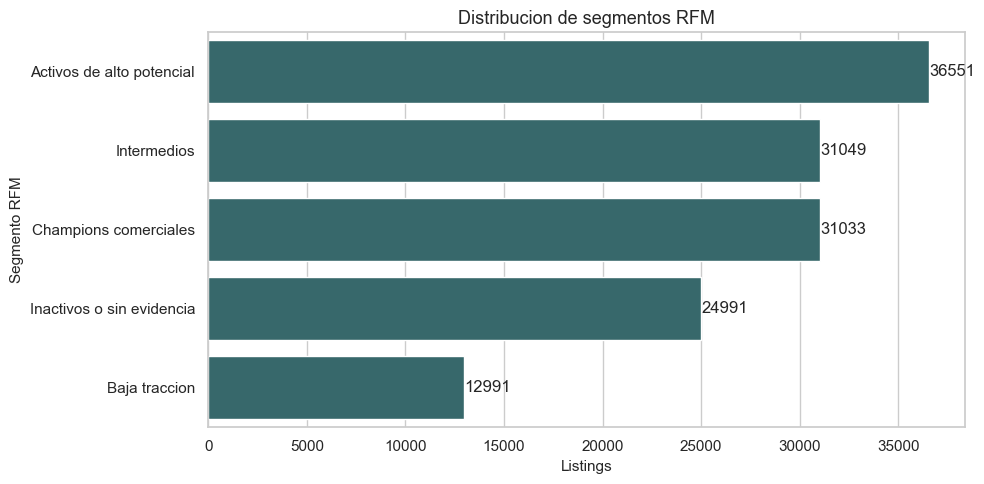

Figura guardada: outputs\figures\rfv_segment_distribution.png


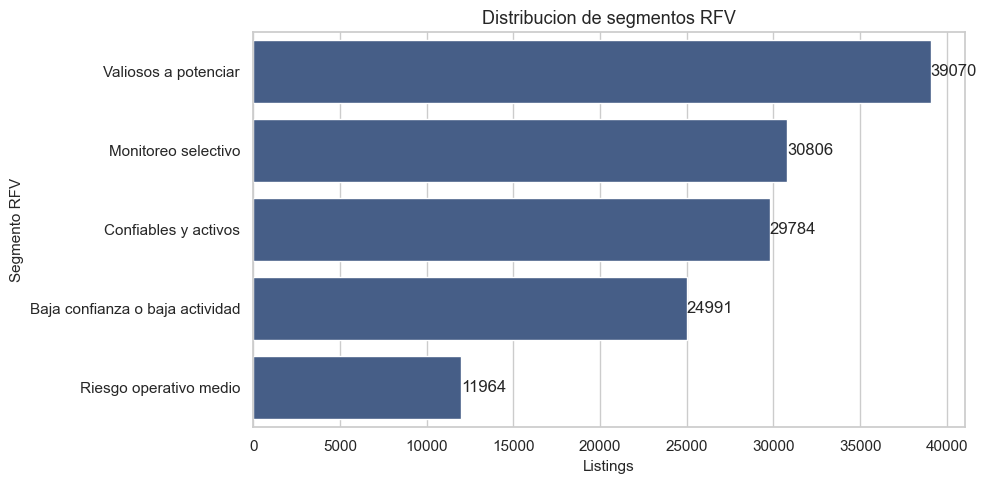

Figura guardada: outputs\figures\rfm_rfv_matrix.png


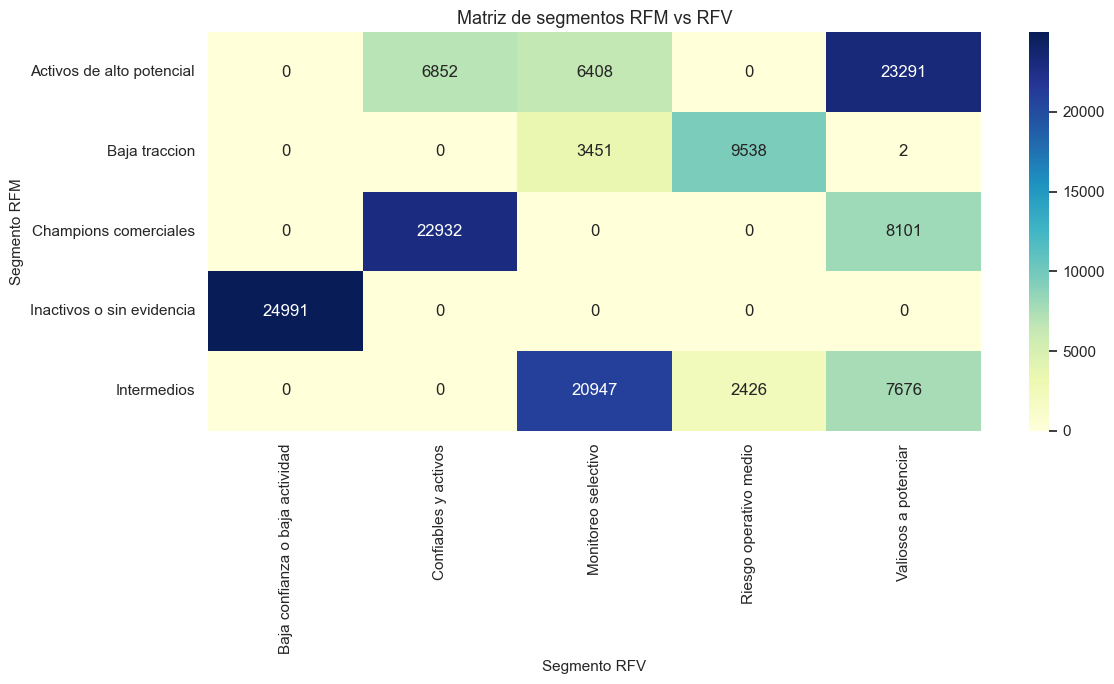

Figura guardada: outputs\figures\rfm_rfv_frequency_monetary_scatter.png


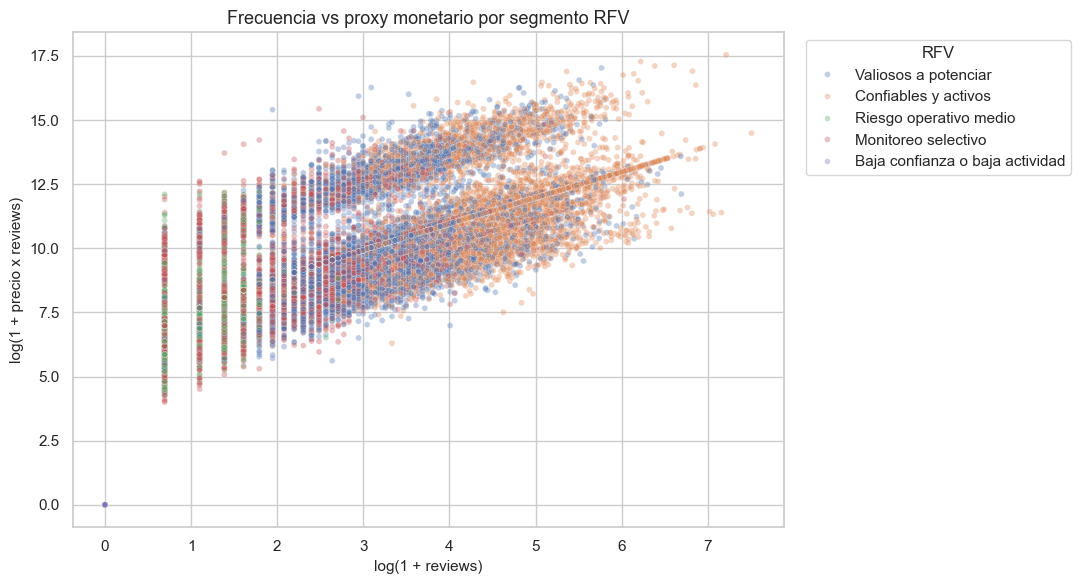

Figura guardada: outputs\figures\rfm_rfv_market_commercial_risk.png


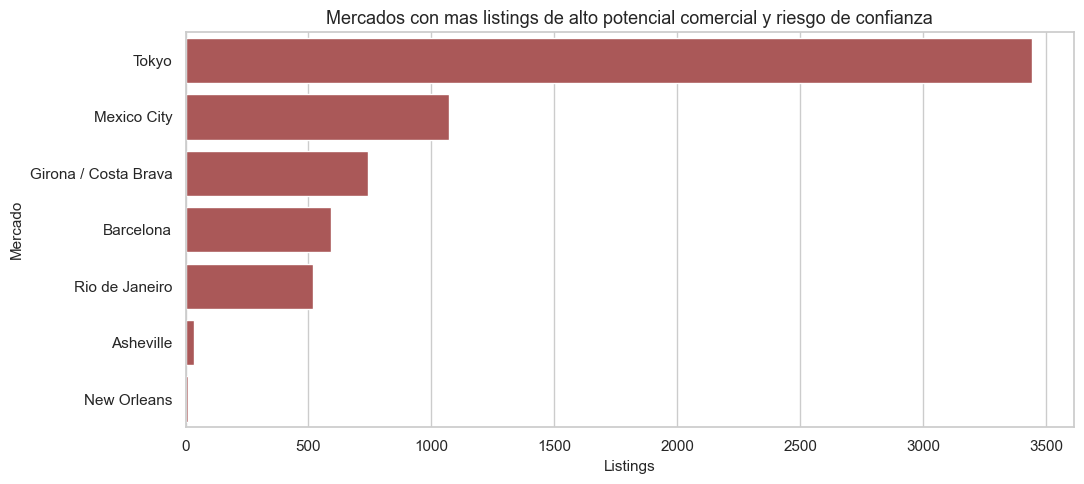

In [7]:
def save_fig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(PROJECT_ROOT)}")

plt.figure(figsize=(10, 5))
order = rfm_summary["rfm_segment"].tolist()
ax = sns.countplot(data=df, y="rfm_segment", order=order, color="#2f6f73")
ax.bar_label(ax.containers[0], fmt="%d")
plt.title("Distribucion de segmentos RFM")
plt.xlabel("Listings")
plt.ylabel("Segmento RFM")
save_fig("rfm_segment_distribution.png")
plt.show()

plt.figure(figsize=(10, 5))
order = rfv_summary["rfv_segment"].tolist()
ax = sns.countplot(data=df, y="rfv_segment", order=order, color="#3b5b92")
ax.bar_label(ax.containers[0], fmt="%d")
plt.title("Distribucion de segmentos RFV")
plt.xlabel("Listings")
plt.ylabel("Segmento RFV")
save_fig("rfv_segment_distribution.png")
plt.show()

matrix = pd.crosstab(df["rfm_segment"], df["rfv_segment"])
plt.figure(figsize=(12, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Matriz de segmentos RFM vs RFV")
plt.xlabel("Segmento RFV")
plt.ylabel("Segmento RFM")
save_fig("rfm_rfv_matrix.png")
plt.show()

sample = df.sample(min(len(df), 25000), random_state=RANDOM_STATE)
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=sample,
    x=np.log1p(sample["frequency_reviews"]),
    y=np.log1p(sample["monetary_proxy"]),
    hue="rfv_segment",
    alpha=0.35,
    s=18,
)
plt.title("Frecuencia vs proxy monetario por segmento RFV")
plt.xlabel("log(1 + reviews)")
plt.ylabel("log(1 + precio x reviews)")
plt.legend(title="RFV", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig("rfm_rfv_frequency_monetary_scatter.png")
plt.show()

top_market = market_summary.sort_values("commercial_risk", ascending=False).head(10)
label_col = "market_label" if "market_label" in top_market.columns else market_group_cols[0]
plt.figure(figsize=(11, 5))
sns.barplot(data=top_market, x="commercial_risk", y=label_col, color="#b84a4a")
plt.title("Mercados con mas listings de alto potencial comercial y riesgo de confianza")
plt.xlabel("Listings")
plt.ylabel("Mercado")
save_fig("rfm_rfv_market_commercial_risk.png")
plt.show()

## Matriz RFM: Recency x Frequency x Monetary

Esta matriz cruza los puntajes RFM principales:

- **Eje X:** `F_QUARTIL`, puntaje de frecuencia.
- **Eje Y:** `R_QUARTIL`, puntaje de recencia.
- **Color:** promedio de `M_QUARTIL`, puntaje monetario.

La primera matriz muestra el valor monetario promedio por combinacion de recencia y frecuencia. La segunda muestra cuantos listings hay en cada combinacion.

Figura guardada: outputs\figures\rfm_matrix_recency_frequency_monetary_score.png


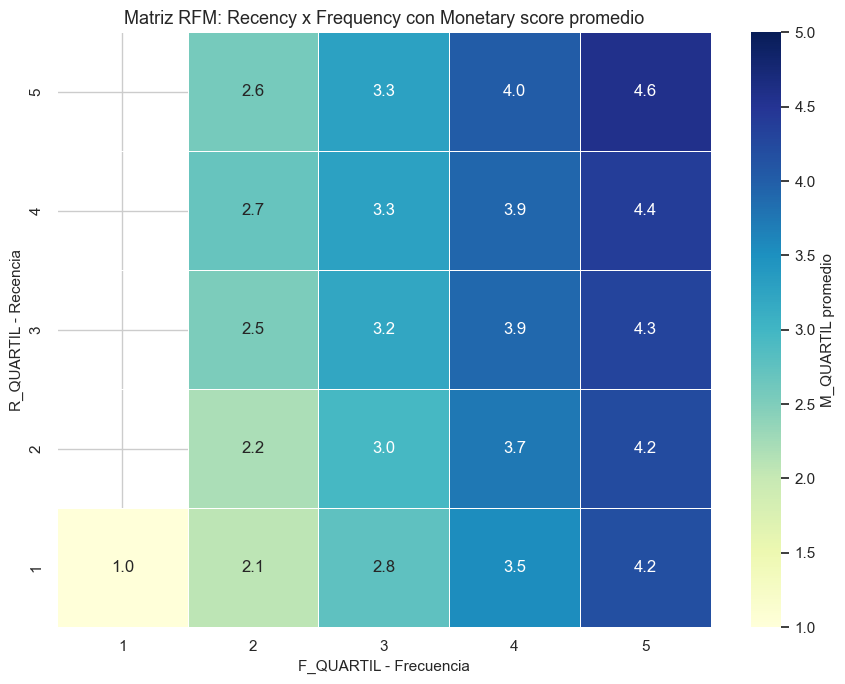

Figura guardada: outputs\figures\rfm_matrix_recency_frequency_listing_count.png


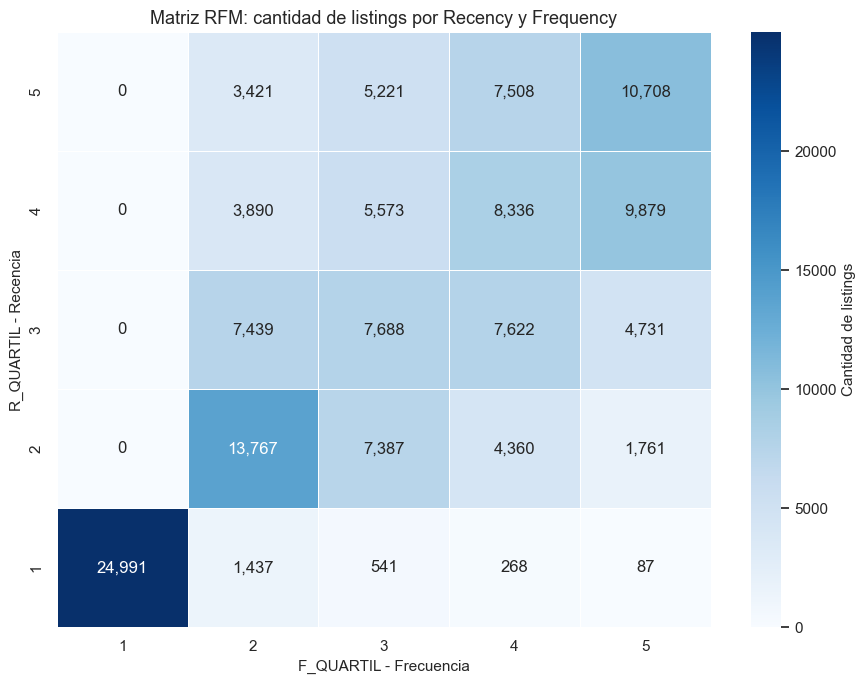

Figura guardada: outputs\figures\rfm_matrix_recency_frequency_rfm_score.png


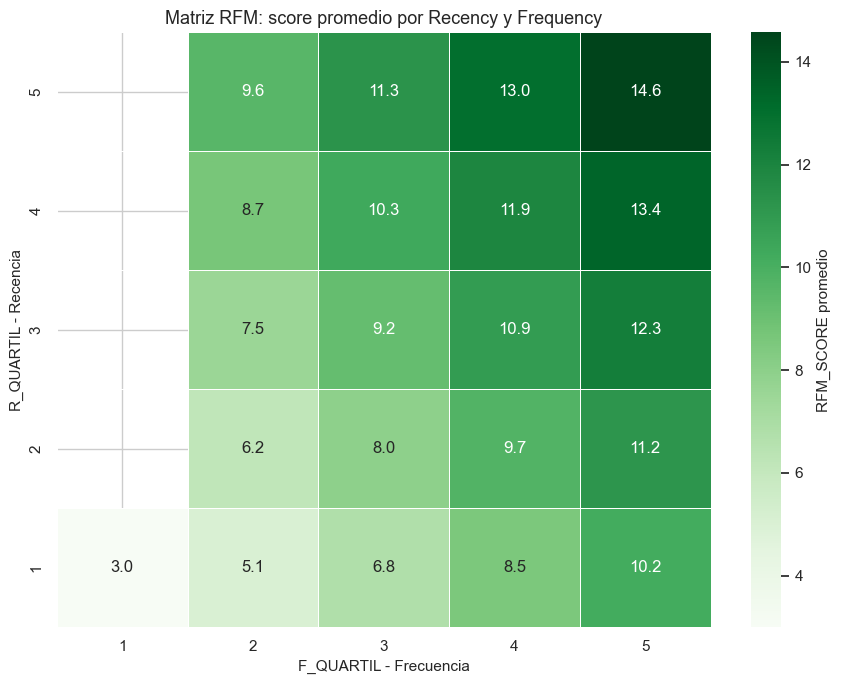

Matriz base RFM por R_QUARTIL y F_QUARTIL:


,r_score,f_score,listings,avg_m_quartil,avg_rfm_score,avg_monetary_proxy
0,1,1,24991,1.000000,3.000000,0.0
1,1,2,1437,2.073069,5.073069,3134.843772
2,1,3,541,2.761553,6.761553,14405.957486
3,1,4,268,3.544776,8.544776,58042.001866
4,1,5,87,4.183908,10.183908,277430.137931
5,2,2,13767,2.201642,6.201642,7648.060035
6,2,3,7387,2.958847,7.958847,38045.189928
7,2,4,4360,3.747477,9.747477,164862.693807
8,2,5,1761,4.220329,11.220329,414743.871948
9,3,2,7439,2.521979,7.521979,14398.933728


In [8]:
# Matriz RFM: Recency score x Frequency score con Monetary score promedio

required_cols = ["listing_id", "r_score", "f_score", "m_score", "rfm_score"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas necesarias para la matriz RFM: {missing_cols}")

rfm_matrix_base = (
    df.groupby(["r_score", "f_score"], dropna=False)
    .agg(
        listings=("listing_id", "count"),
        avg_m_quartil=("m_score", "mean"),
        avg_rfm_score=("rfm_score", "mean"),
        avg_monetary_proxy=("monetary_proxy", "mean"),
    )
    .reset_index()
)

score_order = [1, 2, 3, 4, 5]
recency_order = [5, 4, 3, 2, 1]

monetary_score_matrix = (
    rfm_matrix_base
    .pivot(index="r_score", columns="f_score", values="avg_m_quartil")
    .reindex(index=recency_order, columns=score_order)
)

listings_matrix = (
    rfm_matrix_base
    .pivot(index="r_score", columns="f_score", values="listings")
    .reindex(index=recency_order, columns=score_order)
    .fillna(0)
    .astype(int)
)

rfm_score_matrix = (
    rfm_matrix_base
    .pivot(index="r_score", columns="f_score", values="avg_rfm_score")
    .reindex(index=recency_order, columns=score_order)
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    monetary_score_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=1,
    vmax=5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "M_QUARTIL promedio"},
)
plt.title("Matriz RFM: Recency x Frequency con Monetary score promedio")
plt.xlabel("F_QUARTIL - Frecuencia")
plt.ylabel("R_QUARTIL - Recencia")
save_fig("rfm_matrix_recency_frequency_monetary_score.png")
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(
    listings_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Cantidad de listings"},
)
plt.title("Matriz RFM: cantidad de listings por Recency y Frequency")
plt.xlabel("F_QUARTIL - Frecuencia")
plt.ylabel("R_QUARTIL - Recencia")
save_fig("rfm_matrix_recency_frequency_listing_count.png")
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(
    rfm_score_matrix,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "RFM_SCORE promedio"},
)
plt.title("Matriz RFM: score promedio por Recency y Frequency")
plt.xlabel("F_QUARTIL - Frecuencia")
plt.ylabel("R_QUARTIL - Recencia")
save_fig("rfm_matrix_recency_frequency_rfm_score.png")
plt.show()

print("Matriz base RFM por R_QUARTIL y F_QUARTIL:")
display(rfm_matrix_base.sort_values(["r_score", "f_score"]))

## 7. Interpretacion e implementacion

La combinacion RFM/RFV permite separar decisiones comerciales de decisiones de confianza. Un listing puede tener alta traccion comercial, pero baja confianza operacional; ese caso es prioritario para corregir antes de escalar demanda. Tambien puede ocurrir lo contrario: listings confiables con poca actividad, buenos candidatos para reactivacion o mejora de visibilidad.

In [9]:
total_listings = len(df)
action_summary = (
    df["rfm_rfv_action"]
    .value_counts()
    .rename_axis("accion")
    .reset_index(name="listings")
)
action_summary["listings_pct"] = action_summary["listings"] / total_listings
display(action_summary)

top_rfm = rfm_summary.iloc[0]
top_rfv = rfv_summary.iloc[0]
top_action = action_summary.iloc[0]

best_market = market_summary.sort_values("avg_rfv_score", ascending=False).iloc[0]
risk_market = market_summary.sort_values("commercial_risk", ascending=False).iloc[0]

summary_lines = [
    "# Resumen RFM/RFV - Airbnb",
    "",
    "## Alcance",
    "",
    f"- Unidad de analisis: `listing_id`.",
    f"- Fuente principal: `{source_description}`.",
    f"- Fecha de corte analitica: {analysis_date.date().isoformat()}.",
    "- RFM usa recencia, frecuencia y un proxy monetario `precio x reviews`.",
    "- RFV usa recencia, frecuencia y un proxy de valor/confianza basado en `trust_score` y rating.",
    "- No existen reservas ni gasto real en el repositorio; por tanto, RFM/RFV se presentan como proxies academicos y operativos.",
    "",
    "## Hallazgos principales",
    "",
    f"- Total de listings segmentados: {total_listings:,}.",
    f"- Segmento RFM mas numeroso: {top_rfm['rfm_segment']} ({int(top_rfm['listings']):,} listings; {top_rfm['listings_pct']:.2%}).",
    f"- Segmento RFV mas numeroso: {top_rfv['rfv_segment']} ({int(top_rfv['listings']):,} listings; {top_rfv['listings_pct']:.2%}).",
    f"- Accion operativa mas frecuente: {top_action['accion']} ({int(top_action['listings']):,} listings; {top_action['listings_pct']:.2%}).",
    f"- Mercado con mayor RFV promedio: {best_market.get('market_label', 'N/D')} ({best_market.get('country', 'N/D')}) con RFV promedio {best_market['avg_rfv_score']:.2f}.",
    f"- Mercado con mas listings de alto potencial comercial y riesgo de confianza: {risk_market.get('market_label', 'N/D')} ({risk_market.get('country', 'N/D')}) con {int(risk_market['commercial_risk']):,} listings.",
    "",
    "## Uso recomendado",
    "",
    "- `Mantener y proteger`: listings con buena traccion y buen valor/confianza; monitoreo y retencion.",
    "- `Alto potencial comercial con riesgo de confianza`: prioridad para Trust & Safety y mejora de calidad antes de impulsar demanda.",
    "- `Reactivar demanda de listings confiables`: candidatos para campanas, visibilidad, soporte a hosts o revision de precio.",
    "- `Depurar, corregir o monitorear`: baja traccion y bajo valor/confianza; evaluar completitud, disponibilidad y calidad minima.",
    "",
    "## Limitaciones",
    "",
    "- Reviews se usan como proxy de reservas/actividad.",
    "- Precio por noche se usa como proxy monetario; no representa ingreso real ni comisiones.",
    "- `trust_score` y `risk_segment` son proxies del proyecto, no disputas internas reales.",
]
summary = "\n".join(summary_lines) + "\n"
summary_path = OUTPUT_DIR / "rfm_rfv_resumen_resultados.md"
summary_path.write_text(summary, encoding="utf-8")
print(f"Resumen guardado: {summary_path.relative_to(PROJECT_ROOT)}")
print(summary)

,accion,listings,listings_pct
0,"Depurar, corregir o monitorear",61353,0.449094
1,Mantener y proteger,61176,0.447799
2,Reactivar demanda de listings confiables,7678,0.056202
3,Alto potencial comercial con riesgo de confianza,6408,0.046906


Resumen guardado: outputs\rfm_rfv_resumen_resultados.md
# Resumen RFM/RFV - Airbnb

## Alcance

- Unidad de analisis: `listing_id`.
- Fuente principal: `data/gold/analytics/listing_trust_risk.parquet`.
- Fecha de corte analitica: 2026-02-14.
- RFM usa recencia, frecuencia y un proxy monetario `precio x reviews`.
- RFV usa recencia, frecuencia y un proxy de valor/confianza basado en `trust_score` y rating.
- No existen reservas ni gasto real en el repositorio; por tanto, RFM/RFV se presentan como proxies academicos y operativos.

## Hallazgos principales

- Total de listings segmentados: 136,615.
- Segmento RFM mas numeroso: Activos de alto potencial (36,551 listings; 26.75%).
- Segmento RFV mas numeroso: Valiosos a potenciar (39,070 listings; 28.60%).
- Accion operativa mas frecuente: Depurar, corregir o monitorear (61,353 listings; 44.91%).
- Mercado con mayor RFV promedio: Asheville (United States) con RFV promedio 10.85.
- Mercado con mas listings de alto potencial comercial y riesg